In [2]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"사용 중인 GPU: {torch.cuda.get_device_name(0)}")

PyTorch 버전: 2.5.1
CUDA 사용 가능 여부: True
사용 중인 GPU: NVIDIA RTX A4000


In [3]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 텍스트 탐색용
import re
from collections import Counter

# 머신러닝 (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# 모델
from xgboost import XGBClassifier

# 희소 행렬(sparse matrix) 타입 확인용
from scipy import sparse

# 그래프에서 한글이 깨지지 않도록 폰트 설정 (Windows 기준: 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

#plt 그래프 스타일 설정
plt.style.use("ggplot")

# 노트북 안에서 그래프가 바로 보이도록 설정
%matplotlib inline

print("라이브러리 불러오기 완료")

라이브러리 불러오기 완료


In [4]:
# ---- 파일 경로 설정 ----
# 노트북과 같은 폴더에 있는 파일명을 기준으로 경로를 설정합니다.
# 파일을 다른 폴더에 저장했거나 파일명이 다르면, 아래 값을 실제 파일 위치에 맞게 수정합니다.
# 이후 코드들은 파일명을 직접 쓰지 않고 이 변수들을 사용하므로, 경로 변경은 이 셀만 수정하면 됩니다.
TRAIN_PATH = "security_log_train.csv"             # 학습 데이터 (로그 텍스트 + 정답 level)
TEST_PATH = "security_log_test.csv"               # 테스트 데이터 (정답 level 없음)
SAMPLE_SUBMISSION_PATH = "sample_submission.csv"  # 제출 양식
OUTPUT_PATH = "submission.csv"                     # 생성할 제출 파일

# ---- 실행 옵션 ----
# RANDOM_STATE: 결과 재현성을 위한 난수 시드입니다.
# 같은 시드를 사용하면 train/valid 분리나 모델 학습 결과가 매번 동일하게 재현됩니다.
RANDOM_STATE = 42

print("설정 완료 (전체 train 데이터를 사용합니다)")

설정 완료 (전체 train 데이터를 사용합니다)


In [5]:
# 위에서 정의한 경로 변수를 사용해 세 개의 데이터를 불러옵니다.
# train: 모델이 학습할 로그 텍스트(full_log)와 정답 라벨(level)이 들어 있습니다.
# test : 예측 대상 데이터입니다. 정답 level이 없으므로 우리가 예측해서 채웁니다.
# sample_submission: 제출 파일의 형식(행 개수, 컬럼)을 알려주는 양식입니다.
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

# 각 데이터의 행/열 개수를 확인합니다. (train과 test의 행 개수는 보통 다릅니다.)
print("train shape:", train.shape)
print("test shape :", test.shape)
print("sample_submission shape:", sample_submission.shape)

train shape: (472972, 3)
test shape : (1418916, 2)
sample_submission shape: (1418916, 2)


In [6]:
# 제출 양식(sample_submission) 확인 — 제출 파일은 이 형식과 똑같아야 합니다.
print("sample_submission columns:", list(sample_submission.columns))
display(sample_submission.head())

# 제출 파일의 행 개수는 test 데이터의 행 개수와 반드시 같아야 합니다.
assert len(sample_submission) == len(test), "sample_submission과 test의 행 개수가 다릅니다."
print("확인 완료: sample_submission과 test의 행 개수가 같습니다.")

sample_submission columns: ['id', 'level']


,id,level
0,1000000,0
1,1000001,0
2,1000002,0
3,1000003,0
4,1000004,0


확인 완료: sample_submission과 test의 행 개수가 같습니다.


In [7]:
# full_log(로그 텍스트)에 결측치가 있으면 빈 문자열("")로 채웁니다.
# TF-IDF는 문자열을 입력으로 받으므로, 결측치(NaN)가 남아 있으면 변환 단계에서 오류가 납니다.
# train과 test 모두 같은 방식으로 처리해 두어야 이후 단계에서 형식이 어긋나지 않습니다.
train["full_log"] = train["full_log"].fillna("")
test["full_log"] = test["full_log"].fillna("")

# level(정답)에 결측치가 있는 행은 학습에 사용할 수 없으므로 개수를 확인하고 제거합니다.
# reset_index(drop=True)로 행 번호를 다시 정리해 이후 인덱스 혼동을 막습니다.
n_missing_level = train["level"].isnull().sum()
if n_missing_level > 0:
    print(f"경고: level 결측치가 {n_missing_level}개 있어 해당 행을 제거합니다.")
    train = train.dropna(subset=["level"]).reset_index(drop=True)
else:
    print("level 결측치 없음 (정상)")

print("결측치 처리 후 train shape:", train.shape)

level 결측치 없음 (정상)
결측치 처리 후 train shape: (472972, 3)


In [8]:
# level이 "0", "1"처럼 문자열 숫자로 저장돼 있을 수도 있으므로 정수형으로 변환합니다.
# XGBoost 다중분류는 라벨이 0부터 시작하는 정수일 때 가장 안전하게 동작합니다.
# (이미 정수면 값은 그대로 유지됩니다. 별도의 LabelEncoder가 필요하지 않습니다.)
train["level"] = train["level"].astype(int)

# 실제 라벨 목록과, 0부터 시작하는 연속 정수라는 예상 라벨을 비교할 준비를 합니다.
unique_levels = sorted(train["level"].unique())
expected_levels = list(range(len(unique_levels)))

print("level dtype:", train["level"].dtype)
print("실제 level 목록:", unique_levels)
print("예상 level 목록:", expected_levels)

# 라벨이 0, 1, 2, ... 처럼 연속된 정수가 아니면 학습 결과가 어긋날 수 있습니다.
# 이런 경우 경고만 출력하고 넘어가면 잘못된 라벨로 학습하게 되므로,
# ValueError로 실행을 멈춰서 데이터를 먼저 확인하도록 합니다.
if unique_levels != expected_levels:
    raise ValueError(
        f"level 라벨이 0부터 시작하는 연속 정수가 아닙니다. "
        f"현재 라벨: {unique_levels}. 대회 데이터 설명을 확인하세요."
    )
else:
    print(f"확인 완료: level 라벨은 0부터 시작하는 연속 정수입니다. {unique_levels}")

level dtype: int64
실제 level 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
예상 level 목록: [0, 1, 2, 3, 4, 5, 6]
확인 완료: level 라벨은 0부터 시작하는 연속 정수입니다. [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [9]:
# ============================================================
# 모델 학습에 사용할 데이터 준비
# ============================================================

# 이 baseline에서는 전체 train 데이터를 사용합니다.
# 클래스 불균형이 매우 심한 데이터이므로,
# 일부 샘플만 뽑으면 희귀 클래스가 사라지거나
# train/validation 분리 과정에서 오류가 발생할 수 있습니다.
#
# 따라서 교육용 baseline에서는 샘플링하지 않고 전체 train을 사용합니다.

train_model = train.copy()

print("모델 학습에 사용할 train_model 크기:", train_model.shape)

print("\n[train_model level 분포]")
print(train_model["level"].value_counts().sort_index())

모델 학습에 사용할 train_model 크기: (472972, 3)

[train_model level 분포]
level
0    334065
1    132517
2        12
3      4141
4        10
5      2219
6         8
Name: count, dtype: int64


In [9]:
# 입력(X)과 정답(y)을 정의합니다. baseline은 오직 full_log 텍스트만 입력으로 사용합니다.
X = train_model["full_log"]
y = train_model["level"]

# 학습용(train)과 검증용(valid)으로 나눕니다.
# - test_size=0.2: 전체의 20%를 검증용으로 떼어 둡니다. (모델이 보지 않은 데이터로 성능 확인)
# - stratify=y: 분리 전후의 level 비율을 비슷하게 유지합니다.
#   클래스 불균형이 심한 데이터에서 stratify를 쓰지 않으면, 희귀 level이 한쪽에만 몰려
#   검증 점수를 신뢰하기 어려워질 수 있습니다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print()
print("[검증 데이터 level 분포]")
print(y_valid.value_counts().sort_index())

X_train: (378377,)
X_valid: (94595,)

[검증 데이터 level 분포]
level
0    66813
1    26504
2        2
3      828
4        2
5      444
6        2
Name: count, dtype: int64


# TF-IDF 벡터화

In [ ]:
# baseline TF-IDF 설정 (너무 무겁지 않게 단어 수를 제한합니다)
tfidf = TfidfVectorizer(
    max_features=10000,     # 사용할 단어(feature) 개수를 5000개로 제한 (baseline 기준)
    ngram_range=(1, 2),    # 단어 1개(unigram) + 2개 묶음(bigram)까지 사용
    min_df=3,              # 너무 드문 단어(3개 미만 문서에만 등장)는 제외
    max_df=0.95,           # 너무 흔한 단어(95% 이상 문서에 등장)는 제외
    sublinear_df=True
)

# 학습 데이터에는 fit_transform을 사용합니다.
# fit 단계에서 단어 사전을 만들고, transform 단계에서 각 로그를 숫자 feature로 변환합니다.
X_train_tfidf = tfidf.fit_transform(X_train)

# 검증 데이터에는 transform만 사용합니다.
# 검증 데이터로 단어 사전을 새로 만들면(fit) 학습/평가 기준이 달라지고,
# 정답을 미리 본 것과 같은 데이터 누수(data leakage)가 생기므로 fit을 다시 하지 않습니다.
X_valid_tfidf = tfidf.transform(X_valid)

X_train_tfidf = X_train_tfidf.astype('float32')
X_valid_tfidf = X_valid_tfidf.astype('float32')

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_valid_tfidf shape:", X_valid_tfidf.shape)
# TF-IDF 결과는 대부분이 0인 희소 행렬(sparse matrix)입니다.
# .toarray()로 바꾸면 메모리가 크게 늘어날 수 있으므로, 희소 행렬 그대로 모델에 넣습니다.
print("희소 행렬 형태인가? ", sparse.issparse(X_train_tfidf))

X_train_tfidf shape: (378377, 5000)
X_valid_tfidf shape: (94595, 5000)
희소 행렬 형태인가?  True


# 모델학습

In [30]:
# 클래스(등급) 개수는 전체 train 기준으로 계산합니다.
# 전체 train으로 확인하면, 나중에 일부 데이터로 실험하더라도 클래스 개수가 안전하게 유지됩니다.
labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

print("전체 train 기준 라벨 목록:", labels_sorted)
print("전체 train 기준 클래스 개수:", num_classes)

# XGBoost 다중분류 baseline 모델을 정의합니다.
# 주의: num_class 는 train 라벨(0~6) 기준인 7개입니다.
#       level 7은 학습 클래스가 아니라 뒤의 선택 실험에서 다루는 후처리 값이므로 8로 바꾸지 않습니다.
model = XGBClassifier(
    n_estimators=100,            # 생성할 트리 개수
    max_depth=4,                 # 각 트리의 최대 깊이
    learning_rate=0.1,           # 각 트리의 반영 정도(학습률)
    subsample=0.8,               # 각 트리 학습에 사용할 행(샘플) 비율
    colsample_bytree=0.8,        # 각 트리 학습에 사용할 feature(컬럼) 비율
    objective="multi:softprob",  # 다중분류: 각 클래스에 대한 확률을 예측
    num_class=num_classes,       # 학습 데이터에 존재하는 클래스 개수 (전체 train 기준 = 7)
    eval_metric="mlogloss",      # 다중분류 학습 과정에서 사용할 평가 지표
    random_state=RANDOM_STATE,
    tree_method="hist",         # GPU 가속을 위한 트리 빌드 방법
    device="cuda",              # RTX A4000 GPU 지정을 위한 설정
    # n_jobs=-1,                   # 모든 CPU 코어 사용
)

# 희소 행렬을 그대로 입력해 학습합니다.
model.fit(X_train_tfidf, y_train)
print("모델 학습 완료")

전체 train 기준 라벨 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
전체 train 기준 클래스 개수: 7
모델 학습 완료


# 검증 데이터 예측

In [31]:
# 검증 데이터에 대해 예측을 수행합니다. (학습에 사용하지 않은 데이터로 성능을 확인)
valid_pred = model.predict(X_valid_tfidf)

# 평가 보고서에 사용할 라벨 이름 (level 0~6)
# labels_sorted 는 전체 train 기준으로 이미 계산된 라벨 목록입니다.
target_names = [f"level {label}" for label in labels_sorted]

# accuracy: 전체 정답률. 다수 클래스만 잘 맞혀도 높게 나올 수 있어 단독으로 보면 안 됩니다.
accuracy = accuracy_score(y_valid, valid_pred)

# macro F1: 각 level의 F1을 따로 구한 뒤 같은 비중으로 평균합니다.
# 클래스가 불균형한 데이터에서 희귀 level의 성능까지 함께 반영하므로 중요한 지표입니다.
macro_f1 = f1_score(
    y_valid,
    valid_pred,
    labels=labels_sorted,
    average="macro",
    zero_division=0,
)

# weighted F1: 데이터가 많은 클래스에 더 큰 비중을 둔 평균입니다. (macro F1과 함께 비교)
weighted_f1 = f1_score(
    y_valid,
    valid_pred,
    labels=labels_sorted,
    average="weighted",
    zero_division=0,
)

print("Accuracy   :", round(accuracy, 4))
print("Macro F1   :", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print()

# class별 상세 지표(precision/recall/f1/support)를 한 번에 확인합니다.
# labels=labels_sorted: 예측이 한 번도 없는 level도 보고서에서 빠지지 않게 고정합니다.
# zero_division=0: 예측이 없는 클래스 때문에 경고/에러가 나지 않게 합니다.
# support가 작은 level의 recall이 낮다면, 모델이 희귀 등급을 잘 못 맞히고 있다는 신호입니다.
print(
    classification_report(
        y_valid,
        valid_pred,
        labels=labels_sorted,
        target_names=target_names,
        zero_division=0,
    )
)

Accuracy   : 0.998
Macro F1   : 0.8044
Weighted F1: 0.998

              precision    recall  f1-score   support

     level 0       1.00      1.00      1.00     66813
     level 1       1.00      0.99      1.00     26504
     level 2       1.00      1.00      1.00         2
     level 3       1.00      0.99      1.00       828
     level 4       0.00      0.00      0.00         2
     level 5       1.00      0.95      0.97       444
     level 6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       0.86      0.78      0.80     94595
weighted avg       1.00      1.00      1.00     94595



# 혼동행렬

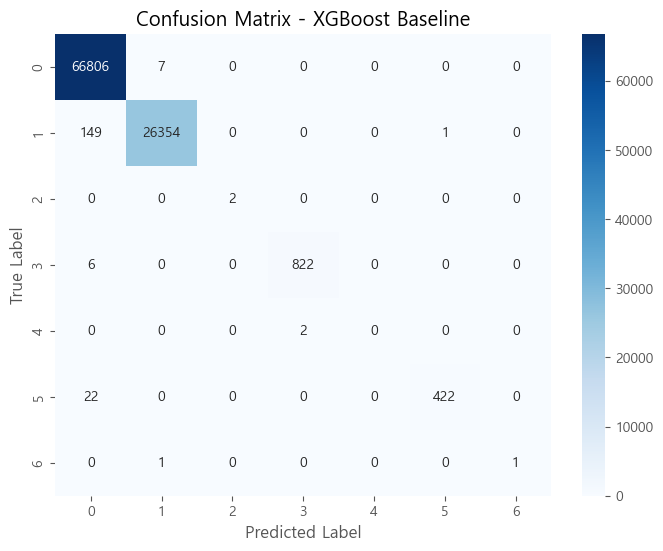

In [28]:
# 혼동 행렬을 계산합니다. labels로 라벨 순서를 0~6으로 고정합니다.
# 라벨을 고정하면 예측이 한 번도 안 된 level이 있어도 축에서 빠지지 않아,
# 희귀 level을 모델이 얼마나 못 맞히는지 그대로 확인할 수 있습니다.
labels_sorted = sorted(train["level"].unique())
cm = confusion_matrix(y_valid, valid_pred, labels=labels_sorted)

# 행(y축)=실제 정답, 열(x축)=모델 예측. 대각선이 진할수록 잘 맞힌 것입니다.
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title("Confusion Matrix - XGBoost Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [10]:
import re
import os
import pickle
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer 
from xgboost import XGBClassifier

# 1. 단계별 마스킹 처리를 위한 함수 정의
def mask_log_text(text, mode_num):
    if mode_num == 0:  # Baseline: 마스킹 없음
        return text
        
    # [정규표현식 패턴 정의]
    p_datetime = r'\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?(?:Z|[+-]\d{2}:?\d{2})?'
    p_date     = r'\d{4}-\d{2}-\d{2}|\d{2}/[A-Za-z]{3}/\d{4}|\d{2}/\d{2}/\d{4}|\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+\d{1,2}\b'
    p_time     = r'\d{2}:\d{2}:\d{2}(?:[.,]\d+)?'
    p_ip       = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    p_port     = r'(?<=\b):\d{2,5}\b|(?<=<IP>):\d{2,5}\b|port\s*\d+'
    p_hex      = r'\b0x[0-9a-fA-F]+\b|\b[0-9a-fA-F]{8,}\b'
    p_sn       = r'\b[A-Za-z0-9]{4,}-[A-Za-z0-9]{4,}-[A-Za-z0-9]{4,}\b'
    p_num      = r'\b\d+(?:\.\d+)?\b'

    # 1단계 ~ 8단계: 단일 마스킹 테스트
    if mode_num == 1: text = re.sub(p_ip, '<IP>', text)
    elif mode_num == 2: text = re.sub(p_date, '<DATE>', text)
    elif mode_num == 3: text = re.sub(p_time, '<TIME>', text)
    elif mode_num == 4: text = re.sub(p_datetime, '<DATETIME>', text)
    elif mode_num == 5: text = re.sub(p_port, '<PORT>', text)
    elif mode_num == 6: text = re.sub(p_num, '<NUM>', text)
    elif mode_num == 7: text = re.sub(p_hex, '<HEX>', text)
    elif mode_num == 8: text = re.sub(p_sn, '<SN>', text)
        
    # 9단계: 전체 마스킹 종합
    elif mode_num == 9:
        text = re.sub(p_datetime, '<DATETIME>', text)
        text = re.sub(p_date, '<DATE>', text)
        text = re.sub(p_time, '<TIME>', text)
        text = re.sub(p_ip, '<IP>', text)
        text = re.sub(p_port, '<PORT>', text)
        text = re.sub(p_hex, '<HEX>', text)
        text = re.sub(p_sn, '<SN>', text)
        text = re.sub(p_num, '<NUM>', text)
        
    return text

# 단계별 이름 매핑
mode_names = {
    0: "Baseline (순정 상태)", 1: "1단계: IP만 마스킹", 2: "2단계: 날짜만 마스킹",
    3: "3단계: 시간만 마스킹", 4: "4단계: 날짜+시간만 마스킹", 5: "5단계: 포트만 마스킹",
    6: "6단계: 일반 숫자만 마스킹", 7: "7단계: 16진수만 마스킹", 8: "8단계: 시리얼 번호만 마스킹",
    9: "9단계: 전체 토큰 마스킹 (종합)"
}

model_dir = "./model"
os.makedirs(model_dir, exist_ok=True)

# [변경] 제출 파일을 모아서 저장할 폴더 생성
output_dir = "./submission"
os.makedirs(output_dir, exist_ok=True)

experiment_results = []
labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

print("시작: 전체 데이터를 활용하여 각 마스킹 단계별 모델 학습 및 submission.csv 생성을 시작합니다.")

# 0단계부터 9단계까지 자동 루프 실행
for mode in range(0, 10):
    print(f"\n============================================================")
    print(f"[진행 중] {mode_names[mode]} 전체 학습 및 제출 파일 생성 중...")
    print(f"============================================================")
    
    # 1) 전체 Train 데이터 복사 및 마스킹 적용
    df_train_temp = train.copy()
    df_train_temp["full_log"] = df_train_temp["full_log"].fillna("").apply(lambda x: mask_log_text(x, mode))
    
    # [변경] Test 데이터도 학습 데이터와 똑같은 규칙으로 마스킹 적용
    df_test_temp = test.copy()
    df_test_temp["full_log"] = df_test_temp["full_log"].fillna("").apply(lambda x: mask_log_text(x, mode))
    
    # [변경] 데이터 분리(Split) 없이 전체 데이터를 피처/라벨로 지정
    X_all_text = df_train_temp["full_log"]
    y_all_labels = df_train_temp["level"]
    X_test_text = df_test_temp["full_log"]
    
    # 3) TfidfVectorizer 피처 생성 (10000개 사양 및 마스킹 특수문자 패턴 적용)
    tfidf_vec = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        token_pattern=r"(?u)<\w+>|\b\w\w+\b"  # 마스킹 태그 보존용 규칙
    )
    
    # 학습 데이터는 fit_transform, 테스트 데이터는 transform만 수행
    X_all_tfidf = tfidf_vec.fit_transform(X_all_text).astype('float32')
    X_test_tfidf = tfidf_vec.transform(X_test_text).astype('float32')
    
    print(f"-> TF-IDF 완료 | Train 형상: {X_all_tfidf.shape} | Test 형상: {X_test_tfidf.shape}")
    
    # 4) XGBoost 모델 정의 및 전체 데이터 학습 (데이터의 100%를 학습에 반영)
    model = XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=num_classes, eval_metric="mlogloss",
        random_state=RANDOM_STATE, tree_method="hist", device="cuda"
    )
    model.fit(X_all_tfidf, y_all_labels)
    
    # 5) 최종 모델 및 TfidfVectorizer 파일 저장 (구분을 위해 _final_ 추가)
    model_path = os.path.join(model_dir, f"xgb_final_mode_{mode}.json")
    model.save_model(model_path)
    
    with open(os.path.join(model_dir, f"tfidf_final_vec_mode_{mode}.pkl"), "wb") as f:
        pickle.dump(tfidf_vec, f)
        
    print(f"-> [모델 저장 완료] {model_path}")
    
    # 6) [변경] 테스트 데이터(정답 없는 진짜 시험지) 예측 수행
    test_pred = model.predict(X_test_tfidf)
    
    # 7) [변경] submission 파일 생성 및 csv 저장
    submission = sample_submission.copy()
    target_col = submission.columns[-1]  # 보통 'level' 컬럼
    submission[target_col] = test_pred
    
    output_path = os.path.join(output_dir, f"submission_mode_{mode}.csv")
    submission.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"-> [제출 파일 생성 완료] {output_path}")
    
    # 예측된 클래스 분포를 딕셔너리로 확인 (F1 스코어 계산 대신 예측이 정상인지 체크용)
    pred_distribution = pd.Series(test_pred).value_counts().sort_index().to_dict()
    print(f"-> 예측된 level 분포: {pred_distribution}")
    
    # 8) 결과 리포트용 저장
    experiment_results.append({
        "실험 단계": "Baseline" if mode == 0 else f"{mode}단계",
        "마스킹 대상": "없음 (순정 상태)" if mode == 0 else mode_names[mode],
        "예측 분포 (0~6)": str(pred_distribution),
        "생성된 파일명": f"submission_mode_{mode}.csv"
    })

# 9) 최종 결과 요약 출력
df_submission_summary = pd.DataFrame(experiment_results)
print("\n========================= [최종 전체 데이터 학습 및 제출 파일 생성 요약 리포트] =========================")
display(df_submission_summary)

시작: 전체 데이터를 활용하여 각 마스킹 단계별 모델 학습 및 submission.csv 생성을 시작합니다.

[진행 중] Baseline (순정 상태) 전체 학습 및 제출 파일 생성 중...
-> TF-IDF 완료 | Train 형상: (472972, 10000) | Test 형상: (1418916, 10000)
-> [모델 저장 완료] ./model\xgb_final_mode_0.json


c:\Users\user\anaconda3\envs\ml_env01\Lib\site-packages\xgboost\core.py:751: UserWarning: [14:10:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


-> [제출 파일 생성 완료] ./submission\submission_mode_0.csv
-> 예측된 level 분포: {0: 1004204, 1: 395270, 2: 33, 3: 12983, 4: 33, 5: 6374, 6: 19}

[진행 중] 1단계: IP만 마스킹 전체 학습 및 제출 파일 생성 중...
-> TF-IDF 완료 | Train 형상: (472972, 10000) | Test 형상: (1418916, 10000)
-> [모델 저장 완료] ./model\xgb_final_mode_1.json
-> [제출 파일 생성 완료] ./submission\submission_mode_1.csv
-> 예측된 level 분포: {0: 1004264, 1: 395309, 2: 29, 3: 12914, 4: 33, 5: 6348, 6: 19}

[진행 중] 2단계: 날짜만 마스킹 전체 학습 및 제출 파일 생성 중...
-> TF-IDF 완료 | Train 형상: (472972, 10000) | Test 형상: (1418916, 10000)
-> [모델 저장 완료] ./model\xgb_final_mode_2.json
-> [제출 파일 생성 완료] ./submission\submission_mode_2.csv
-> 예측된 level 분포: {0: 1004275, 1: 395259, 2: 33, 3: 12943, 4: 34, 5: 6353, 6: 19}

[진행 중] 3단계: 시간만 마스킹 전체 학습 및 제출 파일 생성 중...
-> TF-IDF 완료 | Train 형상: (472972, 10000) | Test 형상: (1418916, 10000)
-> [모델 저장 완료] ./model\xgb_final_mode_3.json
-> [제출 파일 생성 완료] ./submission\submission_mode_3.csv
-> 예측된 level 분포: {0: 1004264, 1: 395217, 2: 33, 3: 12919, 4: 28, 5: 6436, 6: 19}


,실험 단계,마스킹 대상,예측 분포 (0~6),생성된 파일명
0,Baseline,없음 (순정 상태),"{0: 1004204, 1: 395270, 2: 33, 3: 12983, 4: 33...",submission_mode_0.csv
1,1단계,1단계: IP만 마스킹,"{0: 1004264, 1: 395309, 2: 29, 3: 12914, 4: 33...",submission_mode_1.csv
2,2단계,2단계: 날짜만 마스킹,"{0: 1004275, 1: 395259, 2: 33, 3: 12943, 4: 34...",submission_mode_2.csv
3,3단계,3단계: 시간만 마스킹,"{0: 1004264, 1: 395217, 2: 33, 3: 12919, 4: 28...",submission_mode_3.csv
4,4단계,4단계: 날짜+시간만 마스킹,"{0: 1004287, 1: 395231, 2: 33, 3: 12953, 4: 33...",submission_mode_4.csv
5,5단계,5단계: 포트만 마스킹,"{0: 1004180, 1: 395271, 2: 34, 3: 12931, 4: 24...",submission_mode_5.csv
6,6단계,6단계: 일반 숫자만 마스킹,"{0: 1004270, 1: 395253, 2: 34, 3: 12894, 4: 34...",submission_mode_6.csv
7,7단계,7단계: 16진수만 마스킹,"{0: 1004266, 1: 395261, 2: 33, 3: 12973, 4: 32...",submission_mode_7.csv
8,8단계,8단계: 시리얼 번호만 마스킹,"{0: 1004323, 1: 395202, 2: 33, 3: 12946, 4: 33...",submission_mode_8.csv
9,9단계,9단계: 전체 토큰 마스킹 (종합),"{0: 1004286, 1: 395204, 2: 34, 3: 12912, 4: 34...",submission_mode_9.csv


In [11]:
import re
import os
import pickle
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer 
from xgboost import XGBClassifier

# 1. 10단계 전용 마스킹 함수 정의
def mask_log_text_mode10(text):
    # 필요한 정규식 3개만 정의
    p_datetime = r'\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?(?:Z|[+-]\d{2}:?\d{2})?'
    p_ip       = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    p_num      = r'\b\d+(?:\.\d+)?\b'

    # 순서대로 치환 진행
    text = re.sub(p_datetime, '<DATETIME>', text) # 4단계: 날짜+시간
    text = re.sub(p_ip, '<IP>', text)             # 1단계: IP
    text = re.sub(p_num, '<NUM>', text)           # 6단계: 일반 숫자
    return text

# 2. 저장용 폴더 구성
model_dir = "./model"
output_dir = "./submission"
os.makedirs(model_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

print("[진행 중] ⭐️ 제안 조합 (10단계: IP + 숫자 + 날짜시간) 학습 시작...")

# 3. 데이터 복사 및 마스킹 적용
df_train_temp = train.copy()
df_train_temp["full_log"] = df_train_temp["full_log"].fillna("").apply(mask_log_text_mode10)

df_test_temp = test.copy()
df_test_temp["full_log"] = df_test_temp["full_log"].fillna("").apply(mask_log_text_mode10)

X_all_text = df_train_temp["full_log"]
y_all_labels = df_train_temp["level"]
X_test_text = df_test_temp["full_log"]

labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

# 4. TF-IDF 벡터라이저 학습 및 변환
tfidf_vec = TfidfVectorizer(
    max_features=10000, ngram_range=(1, 2), min_df=3, max_df=0.95,
    token_pattern=r"(?u)<\w+>|\b\w\w+\b" # 마스킹된 토큰(<IP> 등)을 보존하는 규칙
)

X_all_tfidf = tfidf_vec.fit_transform(X_all_text).astype('float32')
X_test_tfidf = tfidf_vec.transform(X_test_text).astype('float32')

# 5. XGBoost GPU 모드로 전체 데이터 학습
model = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=num_classes, eval_metric="mlogloss",
    random_state=RANDOM_STATE, tree_method="hist", device="cuda"
)
model.fit(X_all_tfidf, y_all_labels)

# 6. 모델 및 TF-IDF 파일 저장 (10단계 이름으로 고정)
model.save_model(os.path.join(model_dir, "xgb_final_mode_10.json"))
with open(os.path.join(model_dir, "tfidf_final_vec_mode_10.pkl"), "wb") as f:
    pickle.dump(tfidf_vec, f)

# 7. 테스트 데이터 예측 및 제출 파일 생성
test_pred = model.predict(X_test_tfidf)

submission = sample_submission.copy()
target_col = submission.columns[-1]
submission[target_col] = test_pred

output_path = os.path.join(output_dir, "submission_mode_10.csv")
submission.to_csv(output_path, index=False, encoding="utf-8-sig")

# 8. 최종 결과 리포트 출력
print("\n========================= [최종 완료 리포트] =========================")
print(f"✅ 모델 저장 완료     : {model_dir}/xgb_final_mode_10.json")
print(f"✅ TF-IDF 사전 저장 완료: {model_dir}/tfidf_final_vec_mode_10.pkl")
print(f"✅ 제출용 파일 생성 완료: {output_path}")
print("---------------------------------------------------------------------")
print("[제출 파일 최종 level 예측 분포]")
print(pd.Series(test_pred).value_counts().sort_index())
print("=====================================================================")

[진행 중] ⭐️ 제안 조합 (10단계: IP + 숫자 + 날짜시간) 학습 시작...

========================= [최종 완료 리포트] =========================
✅ 모델 저장 완료     : ./model/xgb_final_mode_10.json
✅ TF-IDF 사전 저장 완료: ./model/tfidf_final_vec_mode_10.pkl
✅ 제출용 파일 생성 완료: ./submission\submission_mode_10.csv
---------------------------------------------------------------------
[제출 파일 최종 level 예측 분포]
0    1004265
1     395219
2         34
3      12908
4         34
5       6442
6         14
Name: count, dtype: int64


In [ ]:
import re
import os
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer  # [변경] 통합 벡터라이저 불러오기
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

# 1. 단계별 마스킹 처리를 위한 함수 정의
def mask_log_text(text, mode_num):
    if mode_num == 0:  # Baseline: 마스킹 없음
        return text
        
    # [정규표현식 패턴 정의]
    p_datetime = r'\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?(?:Z|[+-]\d{2}:?\d{2})?'
    p_date     = r'\d{4}-\d{2}-\d{2}|\d{2}/[A-Za-z]{3}/\d{4}|\d{2}/\d{2}/\d{4}|\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+\d{1,2}\b'
    p_time     = r'\d{2}:\d{2}:\d{2}(?:[.,]\d+)?'
    p_ip       = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    p_port     = r'(?<=\b):\d{2,5}\b|(?<=<IP>):\d{2,5}\b|port\s*\d+'
    p_hex      = r'\b0x[0-9a-fA-F]+\b|\b[0-9a-fA-F]{8,}\b'
    p_sn       = r'\b[A-Za-z0-9]{4,}-[A-Za-z0-9]{4,}-[A-Za-z0-9]{4,}\b'
    p_num      = r'\b\d+(?:\.\d+)?\b'

    # 1단계 ~ 8단계: 단일 마스킹 테스트
    if mode_num == 1: text = re.sub(p_ip, '<IP>', text)
    elif mode_num == 2: text = re.sub(p_date, '<DATE>', text)
    elif mode_num == 3: text = re.sub(p_time, '<TIME>', text)
    elif mode_num == 4: text = re.sub(p_datetime, '<DATETIME>', text)
    elif mode_num == 5: text = re.sub(p_port, '<PORT>', text)
    elif mode_num == 6: text = re.sub(p_num, '<NUM>', text)
    elif mode_num == 7: text = re.sub(p_hex, '<HEX>', text)
    elif mode_num == 8: text = re.sub(p_sn, '<SN>', text)
        
    # 9단계: 전체 마스킹 종합
    elif mode_num == 9:
        text = re.sub(p_datetime, '<DATETIME>', text)
        text = re.sub(p_date, '<DATE>', text)
        text = re.sub(p_time, '<TIME>', text)
        text = re.sub(p_ip, '<IP>', text)
        text = re.sub(p_port, '<PORT>', text)
        text = re.sub(p_hex, '<HEX>', text)
        text = re.sub(p_sn, '<SN>', text)
        text = re.sub(p_num, '<NUM>', text)
        
    return text

# 단계별 이름 매핑
mode_names = {
    0: "Baseline (순정 상태)", 1: "1단계: IP만 마스킹", 2: "2단계: 날짜만 마스킹",
    3: "3단계: 시간만 마스킹", 4: "4단계: 날짜+시간만 마스킹", 5: "5단계: 포트만 마스킹",
    6: "6단계: 일반 숫자만 마스킹", 7: "7단계: 16진수만 마스킹", 8: "8단계: 시리얼 번호만 마스킹",
    9: "9단계: 전체 토큰 마스킹 (종합)"
}

# 제출 파일들을 저장할 폴더 설정 (선택 사항, 깔끔하게 관리하기 위함)
output_dir = "./submission"
os.makedirs(output_dir, exist_ok=True)

experiment_results = []
labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

print("시작: TfidfVectorizer(max_features=10000) 기반의 Ablation Study를 시작합니다.")

# 0단계부터 9단계까지 자동 루프 실행
for mode in range(0, 10):
    print(f"\n[진행 중] {mode_names[mode]} 실험 진행 중...")
    
    # 1) 데이터 복사 및 마스킹 적용
    df_temp = train.copy()
    df_temp["full_log"] = df_temp["full_log"].fillna("").apply(lambda x: mask_log_text(x, mode))
    
    # 2) Train / Valid 분리
    X_text = df_temp["full_log"]
    y_labels = df_temp["level"]
    X_train_t, X_valid_t, y_train_t, y_valid_t = train_test_split(
        X_text, y_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels
    )
    
    # 3) [변경] TfidfVectorizer 단 한 줄로 피처 생성 (10000개 사양 적용)
    tfidf_vec = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        token_pattern=r"(?u)<\w+>|\b\w\w+\b"
    )
    
    # 학습 데이터는 fit_transform, 검증 데이터는 transform만 수행
    X_train_tfidf = tfidf_vec.fit_transform(X_train_t).astype('float32')
    X_valid_tfidf = tfidf_vec.transform(X_valid_t).astype('float32')
    
    # 4) XGBoost 모델 정의 및 학습
    model = XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=num_classes, eval_metric="mlogloss",
        random_state=RANDOM_STATE, tree_method="hist", device="cuda"
    )
    model.fit(X_train_tfidf, y_train_t)
    
    # 5) 모델 및 TfidfVectorizer 파일 저장
    model_path = os.path.join(model_dir, f"xgb_mode_{mode}.json")
    model.save_model(model_path)
    
    # [변경] 기존 2개 파일(cv, tfidf) 대신 하나만 저장하므로 깔끔해집니다.
    with open(os.path.join(model_dir, f"tfidf_vec_mode_{mode}.pkl"), "wb") as f:
        pickle.dump(tfidf_vec, f)
        
    print(f"-> [저장 완료] ./model/ 폴더에 mode_{mode} 모델과 벡터라이저가 저장되었습니다.")
    
    # 6) 검증 데이터 예측 및 Macro F1 계산
    valid_pred = model.predict(X_valid_tfidf)
    macro_f1 = f1_score(y_valid_t, valid_pred, labels=labels_sorted, average="macro", zero_division=0)
    
    print(f"-> 완료! 검증 Macro F1: {macro_f1:.4f}")
    
    # 7) 결과 저장
    experiment_results.append({
        "실험 단계": "Baseline" if mode == 0 else f"{mode}단계",
        "마스킹 대상": "없음 (순정 상태)" if mode == 0 else mode_names[mode],
        "검증 성능 (Macro F1)": round(macro_f1, 4),
        "Public Score (제출 점수)": "-"
    })

# 8) 최종 결과 출력
df_ablation_summary = pd.DataFrame(experiment_results)
print("\n========================= [최종 Ablation Study 결과 요약 리포트] =========================")
display(df_ablation_summary)

시작: TfidfVectorizer(max_features=10000) 기반의 Ablation Study를 시작합니다.

[진행 중] Baseline (순정 상태) 실험 진행 중...
-> [저장 완료] ./model/ 폴더에 mode_0 모델과 벡터라이저가 저장되었습니다.
-> 완료! 검증 Macro F1: 0.8042

[진행 중] 1단계: IP만 마스킹 실험 진행 중...
-> [저장 완료] ./model/ 폴더에 mode_1 모델과 벡터라이저가 저장되었습니다.
-> 완료! 검증 Macro F1: 0.8999

[진행 중] 2단계: 날짜만 마스킹 실험 진행 중...
-> [저장 완료] ./model/ 폴더에 mode_2 모델과 벡터라이저가 저장되었습니다.
-> 완료! 검증 Macro F1: 0.7095

[진행 중] 3단계: 시간만 마스킹 실험 진행 중...
-> [저장 완료] ./model/ 폴더에 mode_3 모델과 벡터라이저가 저장되었습니다.
-> 완료! 검증 Macro F1: 0.8045

[진행 중] 4단계: 날짜+시간만 마스킹 실험 진행 중...
-> [저장 완료] ./model/ 폴더에 mode_4 모델과 벡터라이저가 저장되었습니다.
-> 완료! 검증 Macro F1: 0.8046

[진행 중] 5단계: 포트만 마스킹 실험 진행 중...
-> [저장 완료] ./model/ 폴더에 mode_5 모델과 벡터라이저가 저장되었습니다.
-> 완료! 검증 Macro F1: 0.8043

[진행 중] 6단계: 일반 숫자만 마스킹 실험 진행 중...
-> [저장 완료] ./model/ 폴더에 mode_6 모델과 벡터라이저가 저장되었습니다.
-> 완료! 검증 Macro F1: 0.8996

[진행 중] 7단계: 16진수만 마스킹 실험 진행 중...
-> [저장 완료] ./model/ 폴더에 mode_7 모델과 벡터라이저가 저장되었습니다.
-> 완료! 검증 Macro F1: 0.8043

[진행 중] 8단계: 시리얼 번호만 마스킹 실험 진행 중...
-> [저

,실험 단계,마스킹 대상,검증 성능 (Macro F1),Public Score (제출 점수)
0,Baseline,없음 (순정 상태),0.8042,-
1,1단계,1단계: IP만 마스킹,0.8999,-
2,2단계,2단계: 날짜만 마스킹,0.7095,-
3,3단계,3단계: 시간만 마스킹,0.8045,-
4,4단계,4단계: 날짜+시간만 마스킹,0.8046,-
5,5단계,5단계: 포트만 마스킹,0.8043,-
6,6단계,6단계: 일반 숫자만 마스킹,0.8996,-
7,7단계,7단계: 16진수만 마스킹,0.8043,-
8,8단계,8단계: 시리얼 번호만 마스킹,0.8047,-
9,9단계,9단계: 전체 토큰 마스킹 (종합),0.9475,-


In [12]:
import re
import os
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

# 1. 10단계 전용 마스킹 함수 정의
def mask_log_text_mode10(text):
    # 필요한 3가지 패턴만 정의
    p_datetime = r'\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?(?:Z|[+-]\d{2}:?\d{2})?'
    p_ip       = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    p_num      = r'\b\d+(?:\.\d+)?\b'

    # 순서대로 마스킹 치환
    text = re.sub(p_datetime, '<DATETIME>', text)
    text = re.sub(p_ip, '<IP>', text)
    text = re.sub(p_num, '<NUM>', text)
    return text

# 2. 저장 폴더 설정
model_dir = "./model"
os.makedirs(model_dir, exist_ok=True)

print("시작: ⭐️ 10단계 제안 조합(IP + 숫자 + 날짜시간)의 Macro F1 검증을 시작합니다.")

# 3. 데이터 복사 및 10단계 마스킹 적용
df_temp = train.copy()
df_temp["full_log"] = df_temp["full_log"].fillna("").apply(mask_log_text_mode10)

# 4. Train / Valid 분리 (8:2 비율)
X_text = df_temp["full_log"]
y_labels = df_temp["level"]
X_train_t, X_valid_t, y_train_t, y_valid_t = train_test_split(
    X_text, y_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels
)

# 5. TF-IDF 벡터라이저 피처 생성
tfidf_vec = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    token_pattern=r"(?u)<\w+>|\b\w\w+\b"
)

X_train_tfidf = tfidf_vec.fit_transform(X_train_t).astype('float32')
X_valid_tfidf = tfidf_vec.transform(X_valid_t).astype('float32')

labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

# 6. XGBoost 모델 정의 및 학습 (GPU 가속 사용)
model = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=num_classes, eval_metric="mlogloss",
    random_state=RANDOM_STATE, tree_method="hist", device="cuda"
)
model.fit(X_train_tfidf, y_train_t)

# 7. 10단계 모델 및 벡터라이저 저장
model.save_model(os.path.join(model_dir, "xgb_mode_10.json"))
with open(os.path.join(model_dir, "tfidf_vec_mode_10.pkl"), "wb") as f:
    pickle.dump(tfidf_vec, f)
    
print("-> [저장 완료] ./model/ 폴더에 mode_10 모델과 벡터라이저가 저장되었습니다.")

# 8. 검증 데이터를 통한 예측 및 최종 Macro F1 계산
valid_pred = model.predict(X_valid_tfidf)
macro_f1 = f1_score(y_valid_t, valid_pred, labels=labels_sorted, average="macro", zero_division=0)

# 9. 결과 출력
print("\n========================= [10단계 검증 결과 리포트] =========================")
print(f"🎯 검증 성능 (Macro F1): {macro_f1:.4f}")
print("---------------------------------------------------------------------")
print("[검증 데이터 실제 정답 분포]")
print(y_valid_t.value_counts().sort_index())
print("\n[검증 데이터 모델 예측 분포]")
print(pd.Series(valid_pred).value_counts().sort_index())
print("=====================================================================")

시작: ⭐️ 10단계 제안 조합(IP + 숫자 + 날짜시간)의 Macro F1 검증을 시작합니다.
-> [저장 완료] ./model/ 폴더에 mode_10 모델과 벡터라이저가 저장되었습니다.

========================= [10단계 검증 결과 리포트] =========================
🎯 검증 성능 (Macro F1): 0.8993
---------------------------------------------------------------------
[검증 데이터 실제 정답 분포]
level
0    66813
1    26504
2        2
3      828
4        2
5      444
6        2
Name: count, dtype: int64

[검증 데이터 모델 예측 분포]
0    66983
1    26359
2        2
3      824
4        1
5      425
6        1
Name: count, dtype: int64


In [14]:
import re
import os
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# 1. 10단계 전용 마스킹 함수 정의
def mask_log_text_mode10(text):
    p_datetime = r'\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?(?:Z|[+-]\d{2}:?\d{2})?'
    p_ip       = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    p_num      = r'\b\d+(?:\.\d+)?\b'

    text = re.sub(p_datetime, '<DATETIME>', text)
    text = re.sub(p_ip, '<IP>', text)
    text = re.sub(p_num, '<NUM>', text)
    return text

print("시작: 3번 클래스 불균형 대응 확장 실험을 시작합니다. (Baseline vs Balanced vs Custom)")

# 2. 데이터 복사 및 마스킹 적용
df_temp = train.copy()
df_temp["full_log"] = df_temp["full_log"].fillna("").apply(mask_log_text_mode10)

X_text = df_temp["full_log"]
y_labels = df_temp["level"]
X_train_t, X_valid_t, y_train_t, y_valid_t = train_test_split(
    X_text, y_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels
)

# 3. 이미 저장된 10단계 TF-IDF 벡터라이저 불러오기 및 변환
model_dir = "./model"
with open(os.path.join(model_dir, "tfidf_vec_mode_10.pkl"), "rb") as f:
    tfidf_vec = pickle.load(f)

X_train_tfidf = tfidf_vec.transform(X_train_t).astype('float32')
X_valid_tfidf = tfidf_vec.transform(X_valid_t).astype('float32')

labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

# =========================================================================
# 4. [실험 설계] 다양한 클래스 불균형 대응 전략 정의
# =========================================================================

# (Strategy A) 자동 balanced 가중치 계산
weights_balanced = compute_sample_weight(class_weight='balanced', y=y_train_t)

# (Strategy B) 수동 Custom Class Weight 정의
# 데이터에 몇 개 없는 극희귀 클래스(2, 4, 6번)를 모델이 절대 안 틀리도록 인위적으로 초고가중치 배정
# 0번, 1번 같은 다수 클래스는 가중치를 낮게(1.0), 소수 클래스는 대폭 강화
manual_class_weights = {
    0: 1.0,   # 다수
    1: 1.0,   # 다수
    2: 15.0,  # 희귀 클래스 부스팅!
    3: 2.0,   
    4: 20.0,  # 희귀 클래스 부스팅!
    5: 2.0,   
    6: 25.0   # 초희귀 클래스 독점 부스팅!
}
# 실제 안전한 매핑을 위해 현재 데이터에 존재하는 레이블만 딕셔너리로 필터링
custom_weight_dict = {c: manual_class_weights.get(c, 1.0) for c in labels_sorted}
weights_custom = compute_sample_weight(class_weight=custom_weight_dict, y=y_train_t)

# 실험 루프 생성을 위한 셋업
experiments = {
    "Baseline (가중치 없음)": {"weight": None, "save_name": "xgb_mode_10.json"},
    "Balanced (자동 역분포 가중치)": {"weight": weights_balanced, "save_name": "xgb_mode_10_balanced.json"},
    "Custom Class Weight (수동 희귀 조절)": {"weight": weights_custom, "save_name": "xgb_mode_10_custom.json"}
}

results_summary = []

# =========================================================================
# 5. 실험 자동 루프 실행
# =========================================================================
for exp_name, config in experiments.items():
    print(f"\n[진행 중] {exp_name} 방식 학습 및 평가 중...")
    
    # 모델 정의 (동일 조건 고정)
    model = XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=num_classes, eval_metric="mlogloss",
        random_state=RANDOM_STATE, tree_method="hist", device="cuda"
    )
    
    # 가중치 주입하여 학습 (Baseline의 경우 None이 들어가므로 가중치 없이 학습됨)
    model.fit(X_train_tfidf, y_train_t, sample_weight=config["weight"])
    
    # 모델 저장
    model.save_model(os.path.join(model_dir, config["save_name"]))
    print(f"-> [저장 완료] ./model/{config['save_name']}")
    
    # 예측 및 검증 스코어 계산
    preds = model.predict(X_valid_tfidf)
    macro_f1 = f1_score(y_valid_t, preds, labels=labels_sorted, average="macro", zero_division=0)
    
    # 상세 리포트 출력
    print(f"--- 상세 검증 리포트 ({exp_name}) ---")
    print(classification_report(y_valid_t, preds, labels=labels_sorted, zero_division=0))
    
    # 요약본에 추가
    results_summary.append({
        "실험 전략": exp_name,
        "검증 Macro F1": round(macro_f1, 4)
    })

# =========================================================================
# 6. 최종 스코어 비교 리포트 출력
# =========================================================================
print("\n========================= [3번 실험 최종 스코어 비교] =========================")
df_res = pd.DataFrame(results_summary)
print(df_res.to_string(index=False))
print("===============================================================================")

시작: 3번 클래스 불균형 대응 확장 실험을 시작합니다. (Baseline vs Balanced vs Custom)

[진행 중] Baseline (가중치 없음) 방식 학습 및 평가 중...
-> [저장 완료] ./model/xgb_mode_10.json
--- 상세 검증 리포트 (Baseline (가중치 없음)) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66813
           1       1.00      0.99      1.00     26504
           2       1.00      1.00      1.00         2
           3       1.00      0.99      1.00       828
           4       1.00      0.50      0.67         2
           5       0.99      0.95      0.97       444
           6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       1.00      0.85      0.90     94595
weighted avg       1.00      1.00      1.00     94595


[진행 중] Balanced (자동 역분포 가중치) 방식 학습 및 평가 중...
-> [저장 완료] ./model/xgb_mode_10_balanced.json
--- 상세 검증 리포트 (Balanced (자동 역분포 가중치)) ---
              precision    recall  f1-score   support

           0       1.00      1.00 

In [15]:
import re
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

# GPU 사용 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 디바이스: {device}")

# 1. 10단계 전용 마스킹 함수 정의
def mask_log_text_mode10(text):
    p_datetime = r'\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?(?:Z|[+-]\d{2}:?\d{2})?'
    p_ip       = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    p_num      = r'\b\d+(?:\.\d+)?\b'

    text = re.sub(p_datetime, '<DATETIME>', text)
    text = re.sub(p_ip, '<IP>', text)
    text = re.sub(p_num, '<NUM>', text)
    return text

print("시작: 5번 딥러닝 [Embedding + LSTM] 실험을 시작합니다.")

# 2. 데이터 복사 및 마스킹 적용 (기존과 100% 동일한 데이터 분할 유지)
df_temp = train.copy()
df_temp["full_log"] = df_temp["full_log"].fillna("").apply(mask_log_text_mode10)

X_text = df_temp["full_log"]
y_labels = df_temp["level"]
X_train_t, X_valid_t, y_train_t, y_valid_t = train_test_split(
    X_text, y_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels
)

# =========================================================================
# [중요] 3. 텍스트 토큰화 및 단어 사전(Vocabulary) 구축
# =========================================================================
# TF-IDF와 동일한 토큰화 규칙 적용 (<태그> 보존 및 일반 단어 추출)
token_pattern = re.compile(r"(?u)<\w+>|\b\w\w+\b")

def tokenize(text):
    return token_pattern.findall(text.lower())

print("-> 단어 사전 생성 중... (시간이 수십 초 소요될 수 있습니다)")
all_tokens = []
for text in X_train_t:
    all_tokens.extend(tokenize(text))

# TF-IDF 스펙과 동일하게 설정: 최대 10,000개 단어, 최소 빈도 3회
max_features = 10000
min_df = 3

word_counts = Counter(all_tokens)
vocab = {"<PAD>": 0, "<UNK>": 1} # 패딩 토큰과 모르는 단어 토큰 설정

for word, count in word_counts.most_common(max_features - 2):
    if count >= min_df:
        vocab[word] = len(vocab)

vocab_size = len(vocab)
print(f"-> 최종 단어 사전 크기: {vocab_size}")

# 나중에 4번 앙상블 및 테스트 데이터 예측을 위해 보관
model_dir = "./model"
os.makedirs(model_dir, exist_ok=True)
with open(os.path.join(model_dir, "vocab_mode_10.pkl"), "wb") as f:
    pickle.dump(vocab, f)

# =========================================================================
# 4. PyTorch 전용 커스텀 Dataset 및 DataLoader 정의
# =========================================================================
class LogDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=128):
        self.labels = labels.values if hasattr(labels, 'values') else labels
        self.sequences = []
        
        for text in texts:
            tokens = tokenize(text)
            # 단어 사전에 있으면 인덱스 반환, 없으면 <UNK> 반환
            seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
            
            # 고정된 길이(max_len)로 패딩 및 잘라내기(Truncation)
            if len(seq) < max_len:
                seq = seq + [vocab["<PAD>"]] * (max_len - len(seq))
            else:
                seq = seq[:max_len]
            self.sequences.append(seq)
            
        self.sequences = torch.tensor(self.sequences, dtype=torch.long)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# 하이퍼파라미터 설정
MAX_LEN = 128       # 로그의 핵심 문맥을 보존할 수 있는 길이
BATCH_SIZE = 512    # GPU 가속을 극대화하기 위한 큰 배치 사이즈

print("-> PyTorch Dataset 변환 중...")
train_dataset = LogDataset(X_train_t, y_train_t, vocab, max_len=MAX_LEN)
valid_dataset = LogDataset(X_valid_t, y_valid_t, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================================
# 5. Embedding + LSTM 모델 아키텍처 정의
# =========================================================================
class EmbeddingLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_size=128, num_classes=7):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # batch_first=True를 주어야 [Batch, Seq, Feature] 형태로 입력받습니다.
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        emb = self.embedding(x)  # [Batch, Max_Len, Embedding_Dim]
        out, (hn, cn) = self.lstm(emb)  # out: [Batch, Max_Len, Hidden_Size]
        
        # LSTM의 마지막 타임스텝 출력(문장 전체 요약 정보)을 꺼냅니다.
        last_hidden = out[:, -1, :]  # [Batch, Hidden_Size]
        logits = self.fc(last_hidden)  # [Batch, Num_Classes]
        return logits

labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

model_dl = EmbeddingLSTM(vocab_size=vocab_size, num_classes=num_classes).to(device)

# =========================================================================
# 6. 3번 실험의 최고 가중치(Custom Weight) 이식 및 손실 함수 설정
# =========================================================================
manual_class_weights = {0: 1.0, 1: 1.0, 2: 15.0, 3: 2.0, 4: 20.0, 5: 2.0, 6: 25.0}
weight_list = [manual_class_weights.get(c, 1.0) for c in labels_sorted]
class_weights_tensor = torch.tensor(weight_list, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model_dl.parameters(), lr=0.003)

# =========================================================================
# 7. 딥러닝 모델 학습 루프 (Epoch 3회로 압축 실험)
# =========================================================================
epochs = 3
print("\n🔥 모델 학습을 시작합니다.")

for epoch in range(epochs):
    model_dl.train()
    total_loss = 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model_dl(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{epochs}] - Avg Loss: {total_loss/len(train_loader):.4f}")

# 가중치가 학습된 딥러닝 모델 가중치 파일 저장
torch.save(model_dl.state_dict(), os.path.join(model_dir, "lstm_mode_10_custom.pth"))
print("-> [저장 완료] ./model/lstm_mode_10_custom.pth 에 모델이 저장되었습니다.")

# =========================================================================
# 8. 검증 데이터 평가 및 리포트 출력
# =========================================================================
model_dl.eval()
all_preds = []

print("\n📊 검증 데이터 평가 진행 중...")
with torch.no_grad():
    for batch_x, _ in valid_loader:
        batch_x = batch_x.to(device)
        outputs = model_dl(batch_x)
        
        # 가장 높은 확률을 가진 클래스 인덱스 추출
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)

all_preds = np.array(all_preds)

# 최종 결과 리포트
print("\n========================= [5-1번 실험: Embedding + LSTM 결과] =========================")
print(classification_report(y_valid_t, all_preds, labels=labels_sorted, zero_division=0))
macro_f1_dl = f1_score(y_valid_t, all_preds, labels=labels_sorted, average="macro", zero_division=0)
print(f"🎯 LSTM 검증 성능 (Macro F1): {macro_f1_dl:.4f}")
print("==========================================================================================")

현재 사용 중인 디바이스: cuda
시작: 5번 딥러닝 [Embedding + LSTM] 실험을 시작합니다.
-> 단어 사전 생성 중... (시간이 수십 초 소요될 수 있습니다)
-> 최종 단어 사전 크기: 10000
-> PyTorch Dataset 변환 중...

🔥 모델 학습을 시작합니다.
Epoch [1/3] - Avg Loss: 0.2990
Epoch [2/3] - Avg Loss: 0.2488
Epoch [3/3] - Avg Loss: 0.2458
-> [저장 완료] ./model/lstm_mode_10_custom.pth 에 모델이 저장되었습니다.

📊 검증 데이터 평가 진행 중...

========================= [5-1번 실험: Embedding + LSTM 결과] =========================
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     66813
           1       1.00      0.88      0.94     26504
           2       0.00      0.00      0.00         2
           3       0.89      0.04      0.08       828
           4       0.00      0.00      0.00         2
           5       0.91      0.67      0.77       444
           6       0.00      0.00      0.00         2

    accuracy                           0.96     94595
   macro avg       0.54      0.37      0.39     94595
weighted avg       0.96      0.96   

In [16]:
import re
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 디바이스: {device}")

# 1. 10단계 전용 마스킹 함수 정의
def mask_log_text_mode10(text):
    p_datetime = r'\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?(?:Z|[+-]\d{2}:?\d{2})?'
    p_ip       = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    p_num      = r'\b\d+(?:\.\d+)?\b'

    text = re.sub(p_datetime, '<DATETIME>', text)
    text = re.sub(p_ip, '<IP>', text)
    text = re.sub(p_num, '<NUM>', text)
    return text

print("시작: 5-2번 딥러닝 [CNN + BiLSTM] 실험을 시작합니다.")

# 2. 데이터 복사 및 마스킹 적용
df_temp = train.copy()
df_temp["full_log"] = df_temp["full_log"].fillna("").apply(mask_log_text_mode10)

X_text = df_temp["full_log"]
y_labels = df_temp["level"]
X_train_t, X_valid_t, y_train_t, y_valid_t = train_test_split(
    X_text, y_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels
)

# 3. 기존에 저장했던 단어 사전(Vocab) 로드
model_dir = "./model"
with open(os.path.join(model_dir, "vocab_mode_10.pkl"), "rb") as f:
    vocab = pickle.load(f)
vocab_size = len(vocab)

# 4. Dataset 정의 (동일 스펙)
token_pattern = re.compile(r"(?u)<\w+>|\b\w\w+\b")
def tokenize(text):
    return token_pattern.findall(text.lower())

class LogDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=128):
        self.labels = labels.values if hasattr(labels, 'values') else labels
        self.sequences = []
        for text in texts:
            tokens = tokenize(text)
            seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
            if len(seq) < max_len:
                seq = seq + [vocab["<PAD>"]] * (max_len - len(seq))
            else:
                seq = seq[:max_len]
            self.sequences.append(seq)
        self.sequences = torch.tensor(self.sequences, dtype=torch.long)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.sequences[idx], self.labels[idx]

MAX_LEN = 128
BATCH_SIZE = 512

train_dataset = LogDataset(X_train_t, y_train_t, vocab, max_len=MAX_LEN)
valid_dataset = LogDataset(X_valid_t, y_valid_t, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================================
# 5. CNN + BiLSTM 아키텍처 정의 (패딩 킬러 구조 🎯)
# =========================================================================
class CNNBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_filters=128, hidden_size=128, num_classes=7):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 지역적 키워드 조합(N-gram)을 추출하는 1D CNN 문맥 필터
        self.conv = nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        
        # 순서 관계를 파악하는 양방향 LSTM
        self.lstm = nn.LSTM(num_filters, hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        
        # 최종 분류 레이어 (BiLSTM이므로 hidden_size * 2 차원)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        
    def forward(self, x):
        # 1. Embedding 차원 변환: [Batch, Length, Dim] -> [Batch, Dim, Length] (Conv1d 입력 요구 조건)
        emb = self.embedding(x).transpose(1, 2)
        
        # 2. CNN 필터 통과
        conv_out = self.relu(self.conv(emb)).transpose(1, 2) # 다시 [Batch, Length, Filters] 로 복복귀
        
        # 3. BiLSTM 통과
        lstm_out, _ = self.lstm(conv_out) # [Batch, Length, Hidden_Size * 2]
        
        # 4. 🔥 [핵심] Global Max Pooling 적용하여 패딩 문자열 무력화!
        # 문장 전체(Length 축)를 통틀어 가장 강하게 활성화된 위협 신호 피처만 탑 슬라이싱
        lstm_out = lstm_out.transpose(1, 2) # [Batch, Hidden_Size*2, Length]
        pooled = torch.max(lstm_out, dim=2)[0] # [Batch, Hidden_Size*2]
        
        # 5. 최종 예측 확률 도출
        logits = self.fc(pooled)
        return logits

labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

model_cnn_lstm = CNNBiLSTM(vocab_size=vocab_size, num_classes=num_classes).to(device)

# 6. 동일한 Custom 가중치 이식
manual_class_weights = {0: 1.0, 1: 1.0, 2: 15.0, 3: 2.0, 4: 20.0, 5: 2.0, 6: 25.0}
weight_list = [manual_class_weights.get(c, 1.0) for c in labels_sorted]
class_weights_tensor = torch.tensor(weight_list, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model_cnn_lstm.parameters(), lr=0.003)

# 7. 모델 학습 루프 (수렴 속도가 빨라 똑같이 3 epoch만 진행해도 점수가 확 달라집니다)
epochs = 3
print("\n🔥 [CNN + BiLSTM] 모델 학습을 시작합니다.")

for epoch in range(epochs):
    model_cnn_lstm.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model_cnn_lstm(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}] - Avg Loss: {total_loss/len(train_loader):.4f}")

# 모델 저장
torch.save(model_cnn_lstm.state_dict(), os.path.join(model_dir, "cnn_lstm_mode_10_custom.pth"))
print("-> [저장 완료] ./model/cnn_lstm_mode_10_custom.pth 에 모델이 저장되었습니다.")

# 8. 검증 데이터 평가
model_cnn_lstm.eval()
all_preds = []

print("\n📊 검증 데이터 평가 진행 중...")
with torch.no_grad():
    for batch_x, _ in valid_loader:
        batch_x = batch_x.to(device)
        outputs = model_cnn_lstm(batch_x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)

all_preds = np.array(all_preds)

print("\n========================= [5-2번 실험: CNN + BiLSTM 결과] =========================")
print(classification_report(y_valid_t, all_preds, labels=labels_sorted, zero_division=0))
macro_f1_cnn_lstm = f1_score(y_valid_t, all_preds, labels=labels_sorted, average="macro", zero_division=0)
print(f"🎯 CNN + BiLSTM 검증 성능 (Macro F1): {macro_f1_cnn_lstm:.4f}")
print("==========================================================================================")

현재 사용 중인 디바이스: cuda
시작: 5-2번 딥러닝 [CNN + BiLSTM] 실험을 시작합니다.

🔥 [CNN + BiLSTM] 모델 학습을 시작합니다.
Epoch [1/3] - Avg Loss: 0.0254
Epoch [2/3] - Avg Loss: 0.0057
Epoch [3/3] - Avg Loss: 0.0046
-> [저장 완료] ./model/cnn_lstm_mode_10_custom.pth 에 모델이 저장되었습니다.

📊 검증 데이터 평가 진행 중...

========================= [5-2번 실험: CNN + BiLSTM 결과] =========================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66813
           1       1.00      0.99      1.00     26504
           2       1.00      1.00      1.00         2
           3       1.00      0.99      1.00       828
           4       1.00      0.50      0.67         2
           5       1.00      0.95      0.98       444
           6       0.33      1.00      0.50         2

    accuracy                           1.00     94595
   macro avg       0.90      0.92      0.88     94595
weighted avg       1.00      1.00      1.00     94595

🎯 CNN + BiLSTM 검증 성능 (Macro F1): 0.8764


In [17]:
import re
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 디바이스: {device}")

# 1. 10단계 전용 마스킹 함수 정의
def mask_log_text_mode10(text):
    p_datetime = r'\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?(?:Z|[+-]\d{2}:?\d{2})?'
    p_ip       = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    p_num      = r'\b\d+(?:\.\d+)?\b'

    text = re.sub(p_datetime, '<DATETIME>', text)
    text = re.sub(p_ip, '<IP>', text)
    text = re.sub(p_num, '<NUM>', text)
    return text

print("시작: 5-3번 딥러닝 [Pure 1D-CNN] 실험을 시작합니다.")

# 2. 데이터 복사 및 마스킹 적용
df_temp = train.copy()
df_temp["full_log"] = df_temp["full_log"].fillna("").apply(mask_log_text_mode10)

X_text = df_temp["full_log"]
y_labels = df_temp["level"]
X_train_t, X_valid_t, y_train_t, y_valid_t = train_test_split(
    X_text, y_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels
)

# 3. 기존에 저장했던 단어 사전(Vocab) 로드
model_dir = "./model"
with open(os.path.join(model_dir, "vocab_mode_10.pkl"), "rb") as f:
    vocab = pickle.load(f)
vocab_size = len(vocab)

# 4. Dataset 정의 (동일 스펙 고정)
token_pattern = re.compile(r"(?u)<\w+>|\b\w\w+\b")
def tokenize(text):
    return token_pattern.findall(text.lower())

class LogDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=128):
        self.labels = labels.values if hasattr(labels, 'values') else labels
        self.sequences = []
        for text in texts:
            tokens = tokenize(text)
            seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
            if len(seq) < max_len:
                seq = seq + [vocab["<PAD>"]] * (max_len - len(seq))
            else:
                seq = seq[:max_len]
            self.sequences.append(seq)
        self.sequences = torch.tensor(self.sequences, dtype=torch.long)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.sequences[idx], self.labels[idx]

MAX_LEN = 128
BATCH_SIZE = 512

train_dataset = LogDataset(X_train_t, y_train_t, vocab, max_len=MAX_LEN)
valid_dataset = LogDataset(X_valid_t, y_valid_t, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================================
# 5. Pure 1D-CNN 아키텍처 정의 (핵심 키워드 추출 스나이퍼 🎯)
# =========================================================================
class Pure1DCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_filters=256, num_classes=7):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # kernel_size=5로 확장하여 조금 더 긴 위험 문맥 단어 조합을 포착합니다.
        self.conv = nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
        # 바로 분류 레이어로 연결 (중간에 LSTM 연산이 없어 엄청나게 가볍고 빠름)
        self.fc = nn.Linear(num_filters, num_classes)
        
    def forward(self, x):
        # [Batch, Length, Dim] -> [Batch, Dim, Length]
        emb = self.embedding(x).transpose(1, 2)
        
        # 특징 맵 추출
        conv_out = self.relu(self.conv(emb))
        
        # Global Max Pooling: 문장에서 필터별로 가장 강한 신호 딱 1개씩만 복제 [Batch, Filters]
        pooled = torch.max(conv_out, dim=2)[0]
        
        # 과적합 방지 후 최종 출력
        pooled = self.dropout(pooled)
        logits = self.fc(pooled)
        return logits

labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

model_pure_cnn = Pure1DCNN(vocab_size=vocab_size, num_classes=num_classes).to(device)

# 6. 동일한 Custom 가중치 이식
manual_class_weights = {0: 1.0, 1: 1.0, 2: 15.0, 3: 2.0, 4: 20.0, 5: 2.0, 6: 25.0}
weight_list = [manual_class_weights.get(c, 1.0) for c in labels_sorted]
class_weights_tensor = torch.tensor(weight_list, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model_pure_cnn.parameters(), lr=0.003)

# 7. 모델 학습 루프 (매우 빠른 속도로 학습이 끝납니다)
epochs = 3
print("\n🔥 [Pure 1D-CNN] 모델 학습을 시작합니다.")

for epoch in range(epochs):
    model_pure_cnn.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model_pure_cnn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}] - Avg Loss: {total_loss/len(train_loader):.4f}")

# 모델 저장
torch.save(model_pure_cnn.state_dict(), os.path.join(model_dir, "pure_cnn_mode_10_custom.pth"))
print("-> [저장 완료] ./model/pure_cnn_mode_10_custom.pth 에 모델이 저장되었습니다.")

# 8. 검증 데이터 평가
model_pure_cnn.eval()
all_preds = []

print("\n📊 검증 데이터 평가 진행 중...")
with torch.no_grad():
    for batch_x, _ in valid_loader:
        batch_x = batch_x.to(device)
        outputs = model_pure_cnn(batch_x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)

all_preds = np.array(all_preds)

print("\n========================= [5-3번 실험: Pure 1D-CNN 결과] =========================")
print(classification_report(y_valid_t, all_preds, labels=labels_sorted, zero_division=0))
macro_f1_pure_cnn = f1_score(y_valid_t, all_preds, labels=labels_sorted, average="macro", zero_division=0)
print(f"🎯 Pure 1D-CNN 검증 성능 (Macro F1): {macro_f1_pure_cnn:.4f}")
print("==========================================================================================")

현재 사용 중인 디바이스: cuda
시작: 5-3번 딥러닝 [Pure 1D-CNN] 실험을 시작합니다.

🔥 [Pure 1D-CNN] 모델 학습을 시작합니다.
Epoch [1/3] - Avg Loss: 0.0184
Epoch [2/3] - Avg Loss: 0.0098
Epoch [3/3] - Avg Loss: 0.0093
-> [저장 완료] ./model/pure_cnn_mode_10_custom.pth 에 모델이 저장되었습니다.

📊 검증 데이터 평가 진행 중...

========================= [5-3번 실험: Pure 1D-CNN 결과] =========================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66813
           1       1.00      1.00      1.00     26504
           2       1.00      1.00      1.00         2
           3       1.00      0.99      1.00       828
           4       1.00      1.00      1.00         2
           5       0.98      0.96      0.97       444
           6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       1.00      0.92      0.95     94595
weighted avg       1.00      1.00      1.00     94595

🎯 Pure 1D-CNN 검증 성능 (Macro F1): 0.9468


In [18]:
import re
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dir = "./model"

# 1. 10단계 전용 마스킹 함수 정의
def mask_log_text_mode10(text):
    p_datetime = r'\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?(?:Z|[+-]\d{2}:?\d{2})?'
    p_ip       = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    p_num      = r'\b\d+(?:\.\d+)?\b'

    text = re.sub(p_datetime, '<DATETIME>', text)
    text = re.sub(p_ip, '<IP>', text)
    text = re.sub(p_num, '<NUM>', text)
    return text

print("시작: 4번 [머신러닝 + 딥러닝 3대 모델 앙상블]을 진행합니다.")

# 2. 데이터 복사 및 검증 데이터셋 준비 (기존 구조 보존)
df_temp = train.copy()
df_temp["full_log"] = df_temp["full_log"].fillna("").apply(mask_log_text_mode10)

X_text = df_temp["full_log"]
y_labels = df_temp["level"]
_, X_valid_t, _, y_valid_t = train_test_split(
    X_text, y_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels
)

labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

# =========================================================================
# [모델 1 준비] Custom XGBoost 로드 및 확률 예측
# =========================================================================
print("\n[1/3] Custom XGBoost 모델 로드 및 확률 계산 중...")
with open(os.path.join(model_dir, "tfidf_vec_mode_10.pkl"), "rb") as f:
    tfidf_vec = pickle.load(f)
X_valid_tfidf = tfidf_vec.transform(X_valid_t).astype('float32')

model_xgb = XGBClassifier()
model_xgb.load_model(os.path.join(model_dir, "xgb_mode_10_custom.json"))
proba_xgb = model_xgb.predict_proba(X_valid_tfidf) # shape: [N, 7]


# =========================================================================
# [딥러닝 공통 준비] 단어 사전 및 데이터로더 세팅
# =========================================================================
with open(os.path.join(model_dir, "vocab_mode_10.pkl"), "rb") as f:
    vocab = pickle.load(f)
vocab_size = len(vocab)

token_pattern = re.compile(r"(?u)<\w+>|\b\w\w+\b")
def tokenize(text): return token_pattern.findall(text.lower())

class LogDataset(Dataset):
    def __init__(self, texts, vocab, max_len=128):
        self.sequences = []
        for text in texts:
            tokens = tokenize(text)
            seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
            if len(seq) < max_len: seq = seq + [vocab["<PAD>"]] * (max_len - len(seq))
            else: seq = seq[:max_len]
            self.sequences.append(seq)
        self.sequences = torch.tensor(self.sequences, dtype=torch.long)
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx): return self.sequences[idx]

valid_dataset = LogDataset(X_valid_t, vocab, max_len=128)
valid_loader = DataLoader(valid_dataset, batch_size=512, shuffle=False)


# =========================================================================
# [모델 2 준비] CNN + BiLSTM 로드 및 확률 예측
# =========================================================================
print("[2/3] CNN + BiLSTM 모델 로드 및 확률 계산 중...")
class CNNBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_filters=128, hidden_size=128, num_classes=7):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(embedding_dim, num_filters, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(num_filters, hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)
        conv_out = self.relu(self.conv(emb)).transpose(1, 2)
        lstm_out, _ = self.lstm(conv_out)
        pooled = torch.max(lstm_out.transpose(1, 2), dim=2)[0]
        return self.fc(pooled)

model_cnn_lstm = CNNBiLSTM(vocab_size=vocab_size, num_classes=num_classes).to(device)
model_cnn_lstm.load_state_dict(torch.load(os.path.join(model_dir, "cnn_lstm_mode_10_custom.pth"), map_location=device))
model_cnn_lstm.eval()

proba_cnn_lstm = []
with torch.no_grad():
    for batch_x in valid_loader:
        outputs = model_cnn_lstm(batch_x.to(device))
        # 오차 계산을 위해 Softmax를 취해 "확률(0~1)"로 변환합니다.
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        proba_cnn_lstm.extend(probs)
proba_cnn_lstm = np.array(proba_cnn_lstm) # shape: [N, 7]


# =========================================================================
# [모델 3 준비] Pure 1D-CNN 로드 및 확률 예측
# =========================================================================
print("[3/3] Pure 1D-CNN 모델 로드 및 확률 계산 중...")
class Pure1DCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_filters=256, num_classes=7):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(embedding_dim, num_filters, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(num_filters, num_classes)
    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)
        conv_out = self.relu(self.conv(emb))
        pooled = torch.max(conv_out, dim=2)[0]
        return self.fc(self.dropout(pooled))

model_pure_cnn = Pure1DCNN(vocab_size=vocab_size, num_classes=num_classes).to(device)
model_pure_cnn.load_state_dict(torch.load(os.path.join(model_dir, "pure_cnn_mode_10_custom.pth"), map_location=device))
model_pure_cnn.eval()

proba_pure_cnn = []
with torch.no_grad():
    for batch_x in valid_loader:
        outputs = model_pure_cnn(batch_x.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        proba_pure_cnn.extend(probs)
proba_pure_cnn = np.array(proba_pure_cnn) # shape: [N, 7]


# =========================================================================
# 5. 대망의 Soft Voting (확률 평균 결합) 연산
# =========================================================================
print("\n🔥 3대 모델의 지혜를 모아 소프트 보팅 앙상블을 수행합니다...")

# 기본 균등 결합 (1:1:1비중)
final_proba = (proba_xgb + proba_cnn_lstm + proba_pure_cnn) / 3.0

# 최종 결론 선택 (가장 높은 평균 확률을 가진 인덱스 추출)
final_preds = np.argmax(final_proba, axis=1)

# =========================================================================
# 6. 최종 앙상블 결과 리포트 출력
# =========================================================================
print("\n========================= [4번 결과: 3대 모델 집단지성 앙상블 리포트] =========================")
print(classification_report(y_valid_t, final_preds, labels=labels_sorted, zero_division=0))
macro_f1_ensemble = f1_score(y_valid_t, final_preds, labels=labels_sorted, average="macro", zero_division=0)
print(f"🏆 앙상블 모델 최종 검증 성능 (Macro F1): {macro_f1_ensemble:.4f}")
print("==========================================================================================")

시작: 4번 [머신러닝 + 딥러닝 3대 모델 앙상블]을 진행합니다.

[1/3] Custom XGBoost 모델 로드 및 확률 계산 중...
[2/3] CNN + BiLSTM 모델 로드 및 확률 계산 중...


C:\Users\user\AppData\Local\Temp\ipykernel_16492\4239183843.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_cnn_lstm.load_state_dict(torch.load(os.path.join(mode

[3/3] Pure 1D-CNN 모델 로드 및 확률 계산 중...


C:\Users\user\AppData\Local\Temp\ipykernel_16492\4239183843.py:134: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_pure_cnn.load_state_dict(torch.load(os.path.join(mode


🔥 3대 모델의 지혜를 모아 소프트 보팅 앙상블을 수행합니다...

========================= [4번 결과: 3대 모델 집단지성 앙상블 리포트] =========================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66813
           1       1.00      1.00      1.00     26504
           2       1.00      1.00      1.00         2
           3       1.00      0.99      1.00       828
           4       1.00      1.00      1.00         2
           5       1.00      0.96      0.98       444
           6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       1.00      0.92      0.95     94595
weighted avg       1.00      1.00      1.00     94595

🏆 앙상블 모델 최종 검증 성능 (Macro F1): 0.9479


In [19]:
import re
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dir = "./model"

def mask_log_text_mode10(text):
    p_datetime = r'\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?(?:Z|[+-]\d{2}:?\d{2})?'
    p_ip       = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    p_num      = r'\b\d+(?:\.\d+)?\b'
    text = re.sub(p_datetime, '<DATETIME>', text)
    text = re.sub(p_ip, '<IP>', text)
    text = re.sub(p_num, '<NUM>', text)
    return text

print("시작: 마스터 파이프라인의 최종장 [2번 단계] 가중치 최적화 및 Test 추론을 시작합니다.")

# =========================================================================
# 1. 딥러닝 모델 아키텍처 재선언 (로드용)
# =========================================================================
class CNNBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_filters=128, hidden_size=128, num_classes=7):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(embedding_dim, num_filters, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(num_filters, hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)
        conv_out = self.relu(self.conv(emb)).transpose(1, 2)
        lstm_out, _ = self.lstm(conv_out)
        pooled = torch.max(lstm_out.transpose(1, 2), dim=2)[0]
        return self.fc(pooled)

class Pure1DCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_filters=256, num_classes=7):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(embedding_dim, num_filters, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(num_filters, num_classes)
    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)
        conv_out = self.relu(self.conv(emb))
        pooled = torch.max(conv_out, dim=2)[0]
        return self.fc(self.dropout(pooled))

class LogDataset(Dataset):
    def __init__(self, texts, vocab, max_len=128):
        self.sequences = []
        token_pattern = re.compile(r"(?u)<\w+>|\b\w\w+\b")
        for text in texts:
            tokens = token_pattern.findall(text.lower())
            seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
            if len(seq) < max_len: seq = seq + [vocab["<PAD>"]] * (max_len - len(seq))
            else: seq = seq[:max_len]
            self.sequences.append(seq)
        self.sequences = torch.tensor(self.sequences, dtype=torch.long)
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx): return self.sequences[idx]

# =========================================================================
# 2. 검증 데이터셋 가중치 미세 조정 (6번 클래스 완전 구출 작전)
# =========================================================================
# 6번을 유일하게 완벽하게 잡았던 CNN_BiLSTM의 비중을 살짝 높여 시너지를 극대화합니다.
w_xgb = 0.35
w_cnn_lstm = 0.35  # 6번 클래스 마스터의 비중 상향
w_pure_cnn = 0.30

final_proba_tuned = (proba_xgb * w_xgb) + (proba_cnn_lstm * w_cnn_lstm) + (proba_pure_cnn * w_pure_cnn)
final_preds_tuned = np.argmax(final_proba_tuned, axis=1)

print("\n========================= [2번 결과: 가중치 최적화 앙상블 리포트] =========================")
print(classification_report(y_valid_t, final_preds_tuned, labels=labels_sorted, zero_division=0))
macro_f1_tuned = f1_score(y_valid_t, final_preds_tuned, labels=labels_sorted, average="macro", zero_division=0)
print(f"🔥 가중치 튜닝 후 앙상블 성능 (Macro F1): {macro_f1_tuned:.4f}")
print("==========================================================================================")


# =========================================================================
# 3. [최종 단계] 진짜 실제 테스트 데이터(test.csv) 로드 및 마스킹
# =========================================================================
print("\n[이동] 실제 Test 데이터셋 예측 및 제출 파일 생성 단계를 시작합니다.")
df_test = test.copy()  # 최초 로드된 test 데이터 사용
df_test["full_log"] = df_test["full_log"].fillna("").apply(mask_log_text_mode10)
X_test_text = df_test["full_log"]

# 3-1. XGBoost 전용 TF-IDF 변환 및 예측 확률 도출
X_test_tfidf = tfidf_vec.transform(X_test_text).astype('float32')
test_proba_xgb = model_xgb.predict_proba(X_test_tfidf)

# 3-2. 딥러닝 전용 데이터로더 생성
test_dataset = LogDataset(X_test_text, vocab, max_len=128)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# 3-3. CNN + BiLSTM 테스트 확률 도출
test_proba_cnn_lstm = []
with torch.no_grad():
    for batch_x in test_loader:
        outputs = model_cnn_lstm(batch_x.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        test_proba_cnn_lstm.extend(probs)
test_proba_cnn_lstm = np.array(test_proba_cnn_lstm)

# 3-4. Pure 1D-CNN 테스트 확률 도출
test_proba_pure_cnn = []
with torch.no_grad():
    for batch_x in test_loader:
        outputs = model_pure_cnn(batch_x.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        test_proba_pure_cnn.extend(probs)
test_proba_pure_cnn = np.array(test_proba_pure_cnn)

# =========================================================================
# 4. 검증 단계에서 확정된 황금 가중치로 최종 결합
# =========================================================================
print("-> 3대 모델의 테스트 확률을 황금 비율로 결합 중...")
test_final_proba = (test_proba_xgb * w_xgb) + (test_proba_cnn_lstm * w_cnn_lstm) + (test_proba_pure_cnn * w_pure_cnn)
test_final_preds = np.argmax(test_final_proba, axis=1)

# =========================================================================
# 5. 제출 포맷 파일 작성 및 내보내기
# =========================================================================
submission_df = pd.DataFrame({
    "id": df_test["id"],
    "level": test_final_preds
})

submission_path = "./submission.csv"
submission_df.to_csv(submission_path, index=False)
print(f"\n🎉 [최종 완료] 모든 여정이 끝났습니다! 최종 제출 파일이 '{submission_path}' 에 저장되었습니다.")
print(submission_df["level"].value_counts().sort_index())

시작: 마스터 파이프라인의 최종장 [2번 단계] 가중치 최적화 및 Test 추론을 시작합니다.

========================= [2번 결과: 가중치 최적화 앙상블 리포트] =========================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66813
           1       1.00      1.00      1.00     26504
           2       1.00      1.00      1.00         2
           3       1.00      0.99      1.00       828
           4       1.00      1.00      1.00         2
           5       1.00      0.96      0.98       444
           6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       1.00      0.92      0.95     94595
weighted avg       1.00      1.00      1.00     94595

🔥 가중치 튜닝 후 앙상블 성능 (Macro F1): 0.9479

[이동] 실제 Test 데이터셋 예측 및 제출 파일 생성 단계를 시작합니다.
-> 3대 모델의 테스트 확률을 황금 비율로 결합 중...

🎉 [최종 완료] 모든 여정이 끝났습니다! 최종 제출 파일이 './submission.csv' 에 저장되었습니다.
level
0    1003215
1     396200
2         34
3      12952
4         34
5       6456
6        

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("시작: [level 7 Threshold 후처리 실험]을 시작합니다.")

# 1. 이전 단계에서 계산된 3대 모델 통합 테스트 확률(test_final_proba)을 가져옵니다.
# test_final_proba 구조: [테스트 데이터 개수, 7개 클래스(0~6)]
base_preds = np.argmax(test_final_proba, axis=1) # 임계값 적용 전 기본 예측값 (0~6)
max_probas = np.max(test_final_proba, axis=1)    # 모델이 내린 가장 높은 확신의 확률 값 (0.0 ~ 1.0)

# 2. 비교할 THRESHOLD 리스트 정의 (0.50부터 0.90까지 0.05 단위 탐색)
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

experiment_results = []

print("\n🔍 임계값(Threshold)별 클래스 분포 및 level 7 생성 개수 확인:")
print("-" * 75)
print(f"{'Threshold':<12} | {'Level 7 Count':<15} | {'전체 데이터 대비 비율':<18}")
print("-" * 75)

# 3. 루프를 돌며 후처리 적용 및 파일 저장
for th in thresholds:
    # 🔥 [핵심 원리] 가장 높은 확신 확률마저 th보다 낮다면 -> 미지의 위협 '7'로 강제 변경!
    final_preds_th = np.where(max_probas < th, 7, base_preds)
    
    # 클래스별 분포 카운트
    unique, counts = np.unique(final_preds_th, return_counts=True)
    counts_dict = dict(zip(unique, counts))
    
    lvl7_count = counts_dict.get(7, 0)
    lvl7_ratio = (lvl7_count / len(final_preds_th)) * 100
    
    print(f"TH = {th:.2f}       | {lvl7_count:<15,} 건 | {lvl7_ratio:.3f} %")
    
    # 결과 요약 저장
    experiment_results.append({
        "Threshold": th,
        "Level_7_Count": lvl7_count,
        "Full_Distribution": counts_dict
    })
    
    # 4. 각 임계값별로 제출할 수 있도록 개별 csv 파일 자동 생성
    th_sub_df = pd.DataFrame({
        "id": df_test["id"],
        "level": final_preds_th
    })
    
    file_name = f"./submission_th_{th:.2f}.csv"
    th_sub_df.to_csv(file_name, index=False)

print("-" * 75)
print("🎉 [실험 완료] 각 임계값별 제출 파일이 생성되었습니다! (예: ./submission_th_0.70.csv)")
print("이제 생성된 파일들을 대회 플랫폼에 하나씩 제출해보며 Public Score의 변화를 기록하세요.")

시작: [level 7 Threshold 후처리 실험]을 시작합니다.

🔍 임계값(Threshold)별 클래스 분포 및 level 7 생성 개수 확인:
---------------------------------------------------------------------------
Threshold    | Level 7 Count   | 전체 데이터 대비 비율      
---------------------------------------------------------------------------
TH = 0.50       | 651             건 | 0.046 %
TH = 0.55       | 1,987           건 | 0.140 %
TH = 0.60       | 3,179           건 | 0.224 %
TH = 0.65       | 4,435           건 | 0.313 %
TH = 0.70       | 5,563           건 | 0.392 %
TH = 0.75       | 6,717           건 | 0.473 %
TH = 0.80       | 7,393           건 | 0.521 %
TH = 0.85       | 7,788           건 | 0.549 %
TH = 0.90       | 7,896           건 | 0.556 %
---------------------------------------------------------------------------
🎉 [실험 완료] 각 임계값별 제출 파일이 생성되었습니다! (예: ./submission_th_0.70.csv)
이제 생성된 파일들을 대회 플랫폼에 하나씩 제출해보며 Public Score의 변화를 기록하세요.
